In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df=pd.read_csv('ecommerce_customer_data_large.csv')

In [5]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


# Data Cleaning

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [8]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

#### here returns have 47382 null values 


In [10]:
df['Returns'].value_counts(dropna=False)

Returns
1.0    101476
0.0    101142
NaN     47382
Name: count, dtype: int64

In [11]:
df['Returns']=df['Returns'].fillna(0)

#### Missing values in Returns were interpreted as no return activity and replaced with 0.

In [13]:
df.isnull().sum()

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64

In [14]:
df.duplicated().sum()

0

#### the datatype of Purchase Date is wrong

In [16]:
df['Purchase Date']=pd.to_datetime(df['Purchase Date'])

In [17]:
df['Purchase Date'].dtype

dtype('<M8[ns]')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            250000 non-null  int64         
 1   Purchase Date          250000 non-null  datetime64[ns]
 2   Product Category       250000 non-null  object        
 3   Product Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total Purchase Amount  250000 non-null  int64         
 6   Payment Method         250000 non-null  object        
 7   Customer Age           250000 non-null  int64         
 8   Returns                250000 non-null  float64       
 9   Customer Name          250000 non-null  object        
 10  Age                    250000 non-null  int64         
 11  Gender                 250000 non-null  object        
 12  Churn                  250000 non-null  int6


#### Age column is duplicated

In [20]:
(df['Customer Age']==df['Age']).all()

True

In [21]:
df.drop(columns={'Age'},inplace=True)

In [22]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Gender', 'Churn'],
      dtype='object')

In [23]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Customer ID,250000.0,25017.632092,1.0,12590.0,25011.0,37441.25,50000.0,14412.515718
Purchase Date,250000,2021-11-06 19:26:22.286192384,2020-01-01 00:07:26,2020-12-03 08:10:12,2021-11-06 07:39:08.500000,2022-10-11 01:21:56.249999872,2023-09-13 18:42:49,NaN
Product Price,250000.0,254.742724,10.0,132.0,255.0,377.0,500.0,141.738104
Quantity,250000.0,3.004936,1.0,2.0,3.0,4.0,5.0,1.414737
Total Purchase Amount,250000.0,2725.385196,100.0,1476.0,2725.0,3975.0,5350.0,1442.576095
Customer Age,250000.0,43.798276,18.0,30.0,44.0,57.0,70.0,15.364915
Returns,250000.0,0.405904,0.0,0.0,0.0,1.0,1.0,0.491067
Churn,250000.0,0.20052,0.0,0.0,0.0,0.0,1.0,0.40039


### from this we can observe that mean of churn is 20.052% which means 20% customers are already churned

In [25]:
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ','_')
df.columns

Index(['customer_id', 'purchase_date', 'product_category', 'product_price',
       'quantity', 'total_purchase_amount', 'payment_method', 'customer_age',
       'returns', 'customer_name', 'gender', 'churn'],
      dtype='object')

In [26]:
df['gender'].unique()


array(['Female', 'Male'], dtype=object)

In [27]:
df['product_category'].unique()

array(['Home', 'Electronics', 'Books', 'Clothing'], dtype=object)

In [28]:
df['payment_method'].unique()

array(['PayPal', 'Credit Card', 'Cash'], dtype=object)

# Feature Engineering

#### Purchase Year

In [31]:
df['purchase_year']=df['purchase_date'].dt.year

#### Purchase Month

In [33]:
df['purchase_month']=df['purchase_date'].dt.month_name()

#### Purchase Quarter
#### Useful for seasonal analysis.

In [35]:
df['purchase_quarter'] = df['purchase_date'].dt.quarter

#### Day of Week
#### Useful to identify customer shopping behavior.

In [37]:
df['day_of_week']=df['purchase_date'].dt.day_name()

#### Age Group
#### Raw ages aren't very business-friendly.

In [39]:
df['age_group']=pd.cut(df['customer_age'],bins=[18,25,35,45,55,70], labels=[
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '56-70'
    ])

#### Spending Segment
#### Required for customer profiling.

In [41]:
df['spending_segment'] = pd.qcut(
    df['total_purchase_amount'],
    q=3,
    labels=[
        'Low',
        'Medium',
        'High'
    ]
)

#### Return Status

In [43]:
df['return_status'] = df['returns'].map(
    {
        0:'Not Returned',
        1:'Returned'
    }
)

#### Churn Status

In [45]:
df['churn_status']=df['churn'].map({
    0:'Active',
    1:'Churned'
})

In [46]:
print(df['customer_id'].nunique())

49661


In [47]:
df.columns

Index(['customer_id', 'purchase_date', 'product_category', 'product_price',
       'quantity', 'total_purchase_amount', 'payment_method', 'customer_age',
       'returns', 'customer_name', 'gender', 'churn', 'purchase_year',
       'purchase_month', 'purchase_quarter', 'day_of_week', 'age_group',
       'spending_segment', 'return_status', 'churn_status'],
      dtype='object')

# Exploratory Data Analysis (EDA)

#### ====================================
### BUSINESS OVERVIEW
#### ====================================

#### Total Revenue

In [51]:
total_revenue = df['total_purchase_amount'].sum()

print(f"Total Revenue: ${total_revenue:,.0f}")

Total Revenue: $681,346,299


#### Total Transactions

In [53]:
total_transactions = len(df)

print(f"Total Transactions: {total_transactions:,}")

Total Transactions: 250,000


#### Unique Customers

In [55]:
total_customers = df['customer_id'].nunique()

print(f"Unique Customers: {total_customers:,}")

Unique Customers: 49,661


#### Average Order Value

In [57]:
avg_order_value = df['total_purchase_amount'].mean()

print(f"Average Order Value: ${avg_order_value:.2f}")

Average Order Value: $2725.39


#### Return Rate

In [59]:
return_rate = (
    df['returns'].mean()*100
)

print(f"Return Rate: {return_rate:.2f}%")

Return Rate: 40.59%


#### Churn Rate

In [61]:
churn_rate = (
    df['churn'].mean()*100
)

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 20.05%


#### ====================================
### Customer Analysis
#### ====================================


#### Gender Distribution

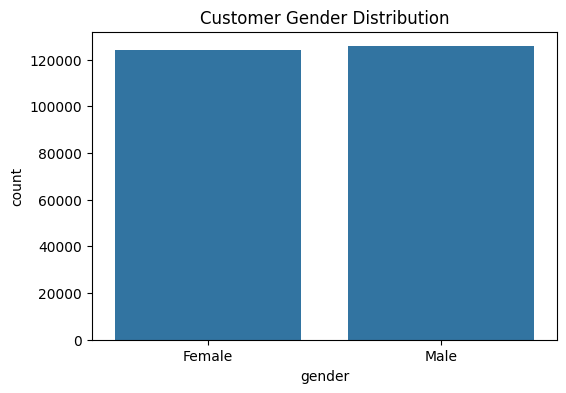

In [64]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='gender'
)

plt.title('Customer Gender Distribution')

plt.show()

#### although both genders contribute the equal amount Males are little more than Female by 1352

#### Age Group Distribution

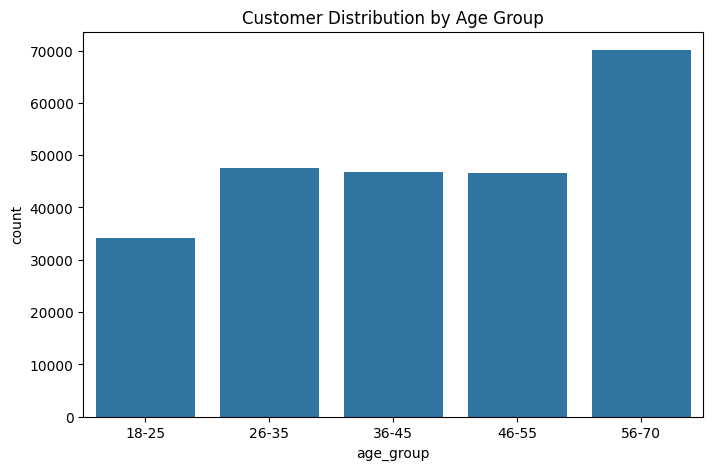

In [67]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='age_group'
)

plt.title('Customer Distribution by Age Group')

plt.show()

#### Executive Summary: Customer Demographics

* **Dominant Market Segment:** The company’s customer base is heavily skewed toward older demographics, with the **56–70 age group** representing the largest market segment, surpassing 70,000 customers. 
* **Growth Opportunity:** Conversely, young adults (**18–25**) represent the smallest segment (approximately 34,000 customers). This indicates a potential market gap and a clear opportunity for targeted marketing campaigns designed to capture and engage a younger audience.

#### ====================================
### Product Analysis
#### ====================================

#### Revenue by Product Category

In [71]:
category_revenue=(df.groupby('product_category')['total_purchase_amount'].sum().sort_values(ascending=False))

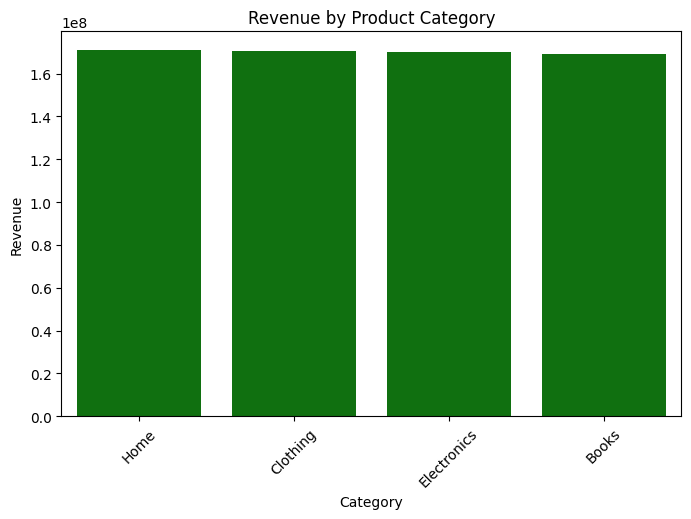

In [72]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values,
    color='green'
)

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

#### Executive Summary: Revenue by Product Category

* **Balanced Portfolio Performance:** Total revenue is exceptionally well-balanced across all major departments, with **Home**, **Clothing**, **Electronics**, and **Books** each generating roughly **$170 million ($1.7 \times 10^8$)**. 
* **Diversification Strength:** No single category acts as a sole dependency or bottleneck for income. This uniform distribution indicates a highly diversified and stable revenue model, mitigating market risks tied to any specific product sector.

#### Product Category Sales Volume

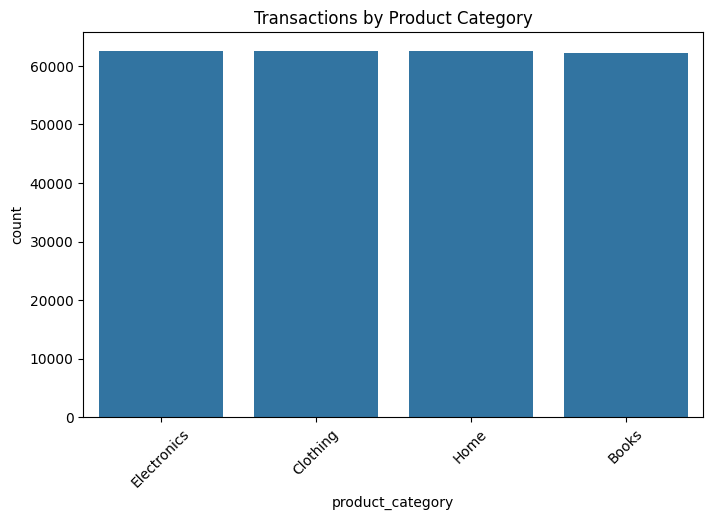

In [75]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='product_category',
    order=df['product_category'].value_counts().index
)

plt.title('Transactions by Product Category')

plt.xticks(rotation=45)

plt.show()

#### Operational Analysis: Transaction Volume Equilibrium

* **Volume Stability:** The distribution of transactions across categories shows near-perfect equilibrium. 
* **Minimal Variance:** **Electronics**, **Clothing**, and **Home** share a dead-heat tie for total volume, while **Books** trails by an incredibly small, negligible margin. This points to uniform transactional health, suggesting that inventory rotation rates and order processing volumes are evenly distributed across warehouse departments.

#### Transaction Analysis

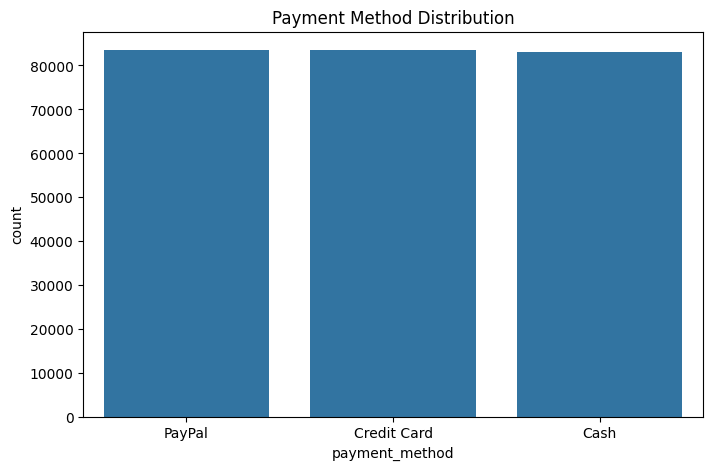

In [78]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='payment_method'
)

plt.title('Payment Method Distribution')

plt.show()

#### Executive Summary: Payment Method Distribution

* **Balanced Checkout Preferences:** Customer payment preferences are split completely evenly across all offered methods, with **PayPal**, **Credit Card**, and **Cash** each accounting for roughly **83,000 transactions**.
* **Omnichannel Flexibility:** The lack of a dominant payment method indicates that the customer base highly values having multiple checkout options, validating the company's decision to maintain a flexible, multi-channel payment gateway.

#### Spending Segment Distribution

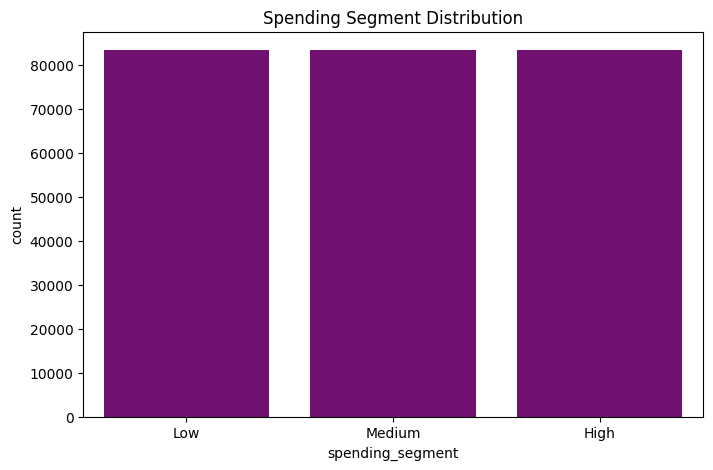

In [81]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='spending_segment',
    color='purple'
)

plt.title('Spending Segment Distribution')

plt.show()

#### Executive Summary: Spending Segment Distribution

* **Symmetric Customer Tiers:** The customer base is perfectly partitioned into equal thirds across financial tiers, with **Low**, **Medium**, and **High** spending segments each containing approximately **83,000 individuals**.
* **Balanced Market Presence:** This flat distribution indicates that the brand appeals equally across different purchasing power demographics, avoiding a reliance on either a high-volume/low-value model or a low-volume/luxury-exclusive model.

# Customer Segmentation (RFM Analysis)

In [84]:
df['purchase_date'].max()

Timestamp('2023-09-13 18:42:49')

#### Since the latest purchase date is:2023-09-13  We'll use

In [130]:
analysis_date = pd.Timestamp('2023-09-14')

### Create RFM Table

In [138]:
rfm=df.groupby('customer_id').agg({
    'purchase_date':lambda x:(analysis_date-x.max()).days,
    'customer_id':'count',
    'total_purchase_amount':'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()


,Recency,Frequency,Monetary
customer_id,,,
1,288,3,6290
2,72,6,16481
3,222,4,9423
4,441,5,7826
5,424,5,9769


In [142]:
rfm.describe().T


,count,mean,std,min,25%,50%,75%,max
Recency,49661.0,261.557580,246.805578,0.0,77.0,187.0,370.0,1351.0
Frequency,49661.0,5.034131,2.199399,1.0,3.0,5.0,6.0,17.0
Monetary,49661.0,13719.947222,6811.065854,125.0,8718.0,13008.0,17921.0,50659.0


#### - Recency measures the number of days since the customer's most recent purchase.
#### - Frequency represents the number of purchases made by the customer.
#### - Monetary represents the total spending by the customer.

## Create RFM Scores
### We score each metric from 1–5.

### Recency Score
#### Lower Recency = Better

In [150]:
rfm['Recency_score']=pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

### Frequency Score
#### Higher Frequency = Better

In [153]:
rfm['Frequency_score']=pd.qcut(
    rfm['Frequency'],
    5,
    labels=[1,2,3,4,5]
)

### Monetary Score

#### Higher Spending = Better

In [156]:
rfm['Monetary_score']=pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [167]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49661 entries, 1 to 50000
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Recency          49661 non-null  int64 
 1   Frequency        49661 non-null  int64 
 2   Monetary         49661 non-null  int64 
 3   Recency_score    49661 non-null  int32 
 4   Frequency_score  49661 non-null  int32 
 5   Monetary_score   49661 non-null  int32 
 6   RFM_score        49661 non-null  object
dtypes: int32(3), int64(3), object(1)
memory usage: 2.5+ MB


In [160]:
rfm['Recency_score']=rfm['Recency_score'].astype(int)
rfm['Frequency_score']=rfm['Frequency_score'].astype(int)
rfm['Monetary_score']=rfm['Monetary_score'].astype(int)

### Create RFM Score

In [165]:
rfm['RFM_score']=(
    rfm['Recency_score'].astype(str)+
    rfm['Frequency_score'].astype(str)+
    rfm['Monetary_score'].astype(str)
)

In [169]:
rfm.head()

,Recency,Frequency,Monetary,Recency_score,Frequency_score,Monetary_score,RFM_score
customer_id,,,,,,,
1,288,3,6290,2,1,1,211
2,72,6,16481,4,4,4,444
3,222,4,9423,3,2,2,322
4,441,5,7826,1,3,2,132
5,424,5,9769,2,3,2,232


### Create Customer Segments

In [172]:
def segment_customer(row):

    if row['Recency_score'] >= 4 and row['Frequency_score'] >= 4 and row['Monetary_score'] >= 4:
        return 'Champions'

    elif row['Recency_score'] >= 3 and row['Frequency_score'] >= 4:
        return 'Loyal Customers'

    elif row['Recency_score'] >= 4 and row['Frequency_score'] <= 3:
        return 'Potential Loyalists'

    elif row['Recency_score'] <= 2 and row['Frequency_score'] >= 3:
        return 'At Risk'

    else:
        return 'Lost Customers'

In [174]:
rfm['customer_segment']=rfm.apply(
    segment_customer,
    axis=1
)

In [180]:
rfm['customer_segment'].value_counts()

customer_segment
Lost Customers         17637
Potential Loyalists     9640
Champions               8680
At Risk                 7829
Loyal Customers         5875
Name: count, dtype: int64

### Visualize Segments

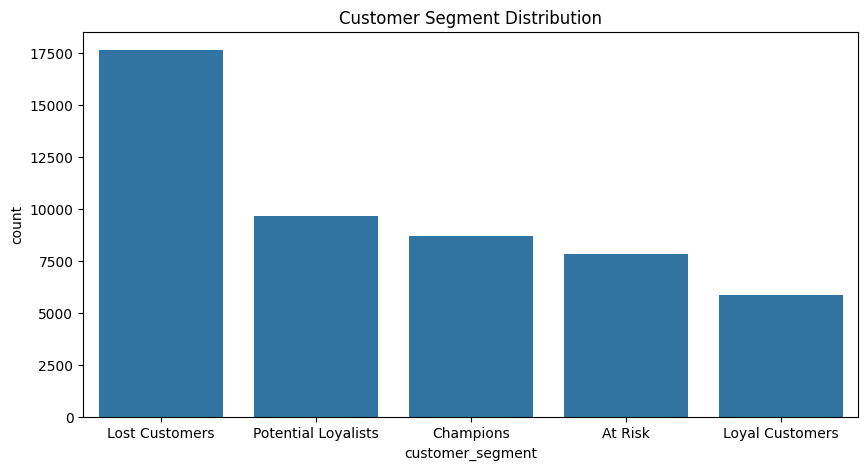

In [185]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=rfm,
    x='customer_segment',
    order=rfm['customer_segment'].value_counts().index
)

plt.title('Customer Segment Distribution')
plt.xticks(rotation=0)

plt.show()

### Executive Summary: Customer Segment Distribution

* **High Churn Risk:** The largest single cohort in the database consists of **Lost Customers** (over 17,500 individuals), outnumbering any other active customer tier. 
* **Healthy Mid-Tier Pipeline:** On a positive note, the business maintains a strong pipeline of highly valuable cohorts, with **Potential Loyalists** (9640) and **Champions** (8680) showing strong engagement. This indicates a solid foundation to build on if retention strategies are prioritized.

### Segment Profile Table

In [192]:
segment_profile = rfm.groupby(
    'customer_segment'
).agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

segment_profile

,Recency,Frequency,Monetary
customer_segment,,,
At Risk,406.03,6.14,16717.99
Champions,60.08,7.66,21718.58
Lost Customers,440.14,3.19,8721.33
Loyal Customers,152.93,6.99,17740.96
Potential Loyalists,65.11,3.96,10777.78


# Purchase Pattern Analysis

## we answer:
### How, when, and through which channels customers make purchases?

Objective

Analyze purchasing behavior to identify:

Seasonal trends,
Monthly sales patterns,
Weekly purchasing behavior,
Category preferences,
Customer demographic spending patterns,
Payment preferences.

### Monthly Revenue Trend
#### How does revenue change over time?

In [205]:
monthly_sales = (
    df.groupby('purchase_month')['total_purchase_amount']
    .sum()
    .reindex([
        'January','February','March','April',
        'May','June','July','August',
        'September','October','November','December'
    ])
)

monthly_sales

purchase_month
January      62201958
February     57050354
March        62355745
April        60217450
May          62533980
June         60286066
July         62587751
August       63063912
September    51763012
October      46595245
November     45604668
December     47086158
Name: total_purchase_amount, dtype: int64

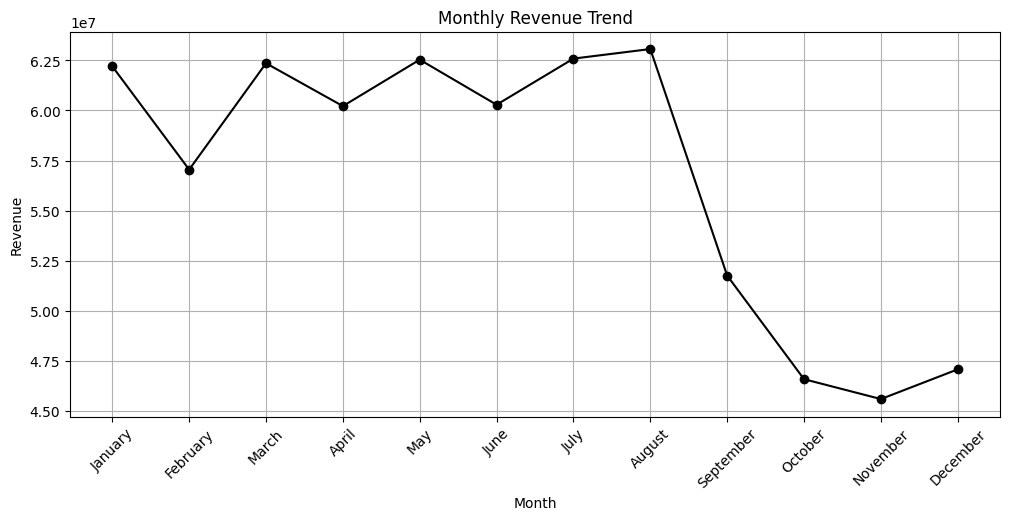

In [222]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    color='black',
    
)
plt.grid()
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

### Executive Summary: Monthly Revenue Performance

* **Highest Revenue Month:** Revenue peaked in **August**, reaching its highest point of the year at approximately **63.1 million**.
* **Lowest Revenue Month:** Performance hit its lowest trough in **November**, dropping down to approximately **45.6 million**.
* **Seasonal Peaks & Patterns:** The business experiences a strong, sustained **Spring/Summer peak period** spanning from January through August, where monthly revenue consistently stays above the 60 million mark (with a brief, singular dip in February to around 57 million).

### Quarterly Revenue Analysis
#### Which quarter contributes the most revenue?

In [229]:
quarterly_sales = (
    df.groupby('purchase_quarter')
    ['total_purchase_amount']
    .sum()
)

quarterly_sales

purchase_quarter
1    181608057
2    183037496
3    177414675
4    139286071
Name: total_purchase_amount, dtype: int64

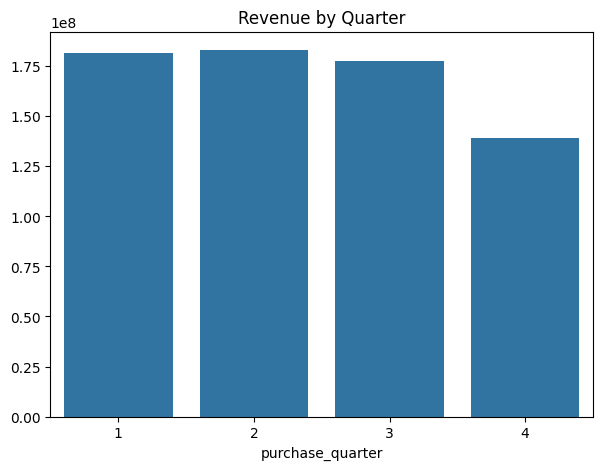

In [231]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=quarterly_sales.index,
    y=quarterly_sales.values
)

plt.title('Revenue by Quarter')

plt.show()

### Executive Summary: Quarterly Revenue Performance

* **Strongest Quarter:** Revenue reached its peak in **Quarter 2 (Q2)**, bringing in the highest earnings of the year at approximately **183 million**. 
* **Weakest Quarter:** Performance saw a noticeable drop in **Quarter 4 (Q4)**, serving as the lowest-performing period with earnings falling to approximately **139 million**.
* **Overall Trend:** The business maintains high and stable performance through the first nine months of the year—with Q1, Q2, and Q3 all consistently staying well above the 175 million mark—before experiencing a sharp contraction heading into the final quarter.

### Day of Week Analysis
#### On which days do customers spend the most?

In [235]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_sales = (
    df.groupby('day_of_week')
    ['total_purchase_amount']
    .sum()
    .reindex(day_order)
)

day_sales

day_of_week
Monday       96842007
Tuesday      96894118
Wednesday    98336024
Thursday     97990590
Friday       97178917
Saturday     97466717
Sunday       96637926
Name: total_purchase_amount, dtype: int64

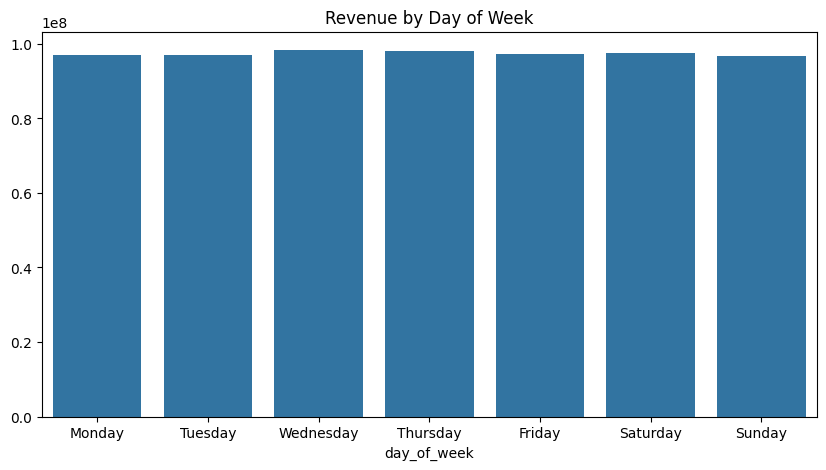

In [237]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=day_sales.index,
    y=day_sales.values
)

plt.title('Revenue by Day of Week')

plt.show()

### Executive Summary: Daily Revenue Performance

* **Absence of a Weekend Effect:** There is no notable "weekend effect" present in the data. Sunday and Saturday performance shows no significant spike or drop compared to the rest of the week, indicating that customer shopping behavior remains independent of traditional weekend leisure cycles.
* **Weekday Stability:** The distribution demonstrates complete equilibrium and consistent weekday dominance. Revenue is virtually flat from Monday through Sunday, with every single day generating approximately **96 million to 98 million**. 
* **Minor Fluctuations:** **Wednesday** holds a negligible lead as the highest revenue-generating day of the week, while **Sunday** sits marginally at the bottom of the distribution, though the overall variance between the two is entirely insignificant.

### Revenue by Product Category

In [241]:
category_revenue

product_category
Home           171138916
Clothing       170716122
Electronics    170146025
Books          169345236
Name: total_purchase_amount, dtype: int64

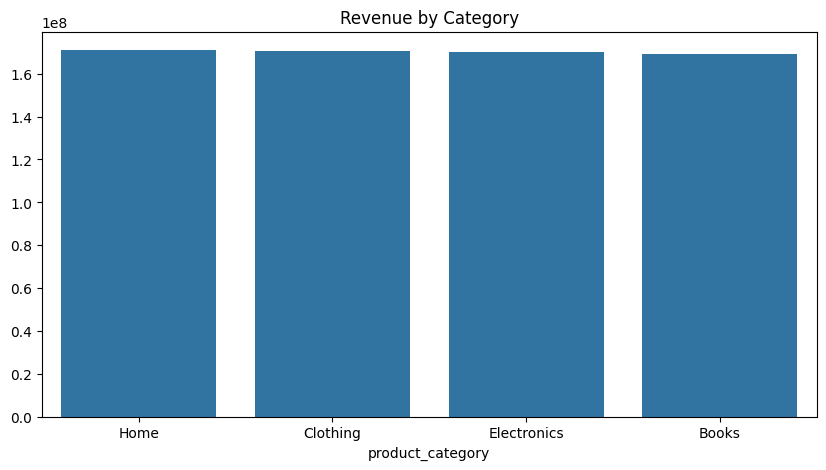

In [243]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title('Revenue by Category')

plt.show()

#### Operational Analysis: Transaction Volume Equilibrium

* **Volume Stability:** The distribution of transactions across categories shows near-perfect equilibrium. 
* **Minimal Variance:** **Electronics**, **Clothing**, and **Home** share a dead-heat tie for total volume, while **Books** trails by an incredibly small, negligible margin. This points to uniform transactional health, suggesting that inventory rotation rates and order processing volumes are evenly distributed across warehouse departments.

### Revenue by Age Group
#### Which age groups contribute the most revenue?

In [250]:
age_revenue = (
    df.groupby('age_group')
    ['total_purchase_amount']
    .sum()
)

age_revenue

C:\Users\Ajay\AppData\Local\Temp\ipykernel_8868\1393421687.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')


age_group
18-25     89071690
26-35    126847260
36-45    126471620
46-55    128317991
56-70    198153447
Name: total_purchase_amount, dtype: int64

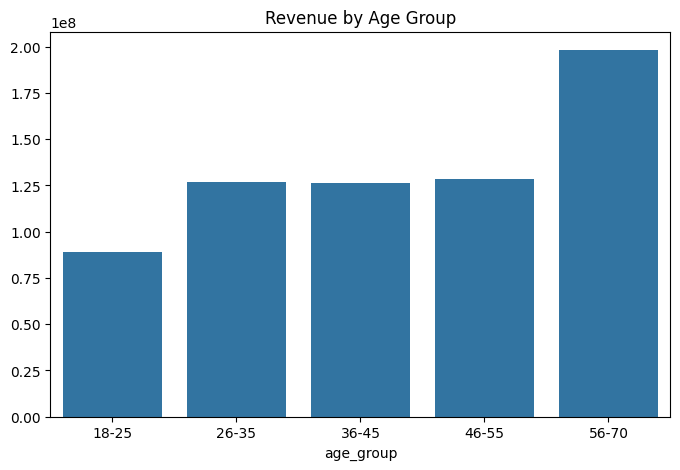

In [252]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=age_revenue.index,
    y=age_revenue.values
)

plt.title('Revenue by Age Group')

plt.show()

### Executive Summary: Revenue by Age Group

* **Highest Revenue Age Group:** The **56–70 age group** is the primary economic driver for the business, generating the highest total revenue at approximately **198 million**.
* **Lowest Revenue Age Group:** The **18–25 age group** contributes the least financially, serving as the lowest revenue-generating segment at approximately **89 million**.
* **The Middle-Age Plateau:** Revenue contribution displays a distinct "plateau effect" across middle-aged demographics. Contributions remain remarkably stable and stagnant across the **26–35, 36–45, and 46–55 age groups**, with each tier consistently bringing in roughly **126 million to 128 million**.

### Revenue by Gender

In [260]:
gender_revenue = (
    df.groupby('gender')
    ['total_purchase_amount']
    .sum()
)

gender_revenue



gender
Female    338559456
Male      342786843
Name: total_purchase_amount, dtype: int64

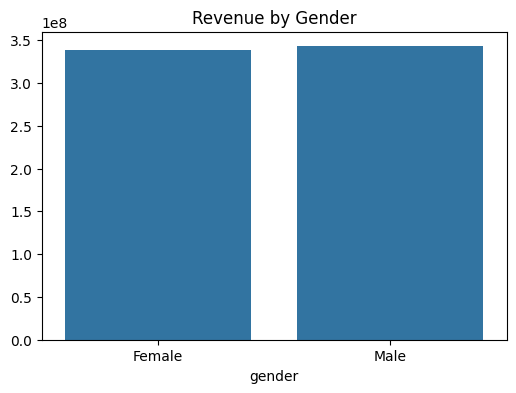

In [262]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=gender_revenue.index,
    y=gender_revenue.values
)

plt.title('Revenue by Gender')

plt.show()

### Executive Summary: Revenue by Gender

* **Highest Revenue Gender:** Male customers represent the top-performing demographic, contributing approximately **342.8 million** to the total purchase amount.
* **Lowest Revenue Gender:** Female customers follow closely as the secondary demographic, contributing approximately **338.6 million**.
* **Near-Perfect Gender Parity:** The data highlights an exceptionally balanced market split, with a marginal variance of less than 1.3% between male and female spending. This indicates that the brand's product offerings and marketing possess equal appeal across genders, showing no significant reliance on a single demographic.

### Revenue by Payment Method

In [266]:
payment_revenue = (
    df.groupby('payment_method')
    ['total_purchase_amount']
    .sum()
)

payment_revenue

payment_method
Cash           225423854
Credit Card    228822915
PayPal         227099530
Name: total_purchase_amount, dtype: int64

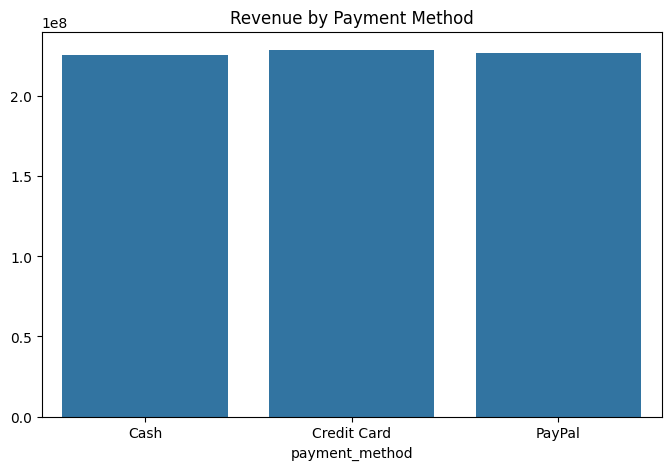

In [268]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_revenue.index,
    y=payment_revenue.values
)

plt.title('Revenue by Payment Method')

plt.show()

Summary: Revenue by Payment Method

* **Highest Revenue Channel:** **Credit Card** transactions serve as the top-performing payment method, bringing in the highest total revenue at approximately **228 million**.
* **Balanced Revenue Channels:** The remaining methods follow in an incredibly tight sequence. **PayPal** serves as the second-highest channel at roughly **226 million**, while **Cash** transactions trail closely at approximately **225 million**.
* **Revenue Distribution Parity:** The data demonstrates near-perfect parity across all payment gateways, with a total spread of less than 1.5% between the highest and lowest channels. This points to highly flexible customer transaction preferences and balanced processing volumes across both digital and physical payment infrastructures.

### Average Purchase Value by Category
#### Which category has the highest average transaction value?

In [272]:
avg_category_value = (
    df.groupby('product_category')
    ['total_purchase_amount']
    .mean()
    .sort_values(ascending=False)
)

avg_category_value

product_category
Home           2736.383806
Clothing       2727.922564
Books          2720.536508
Electronics    2716.685694
Name: total_purchase_amount, dtype: float64

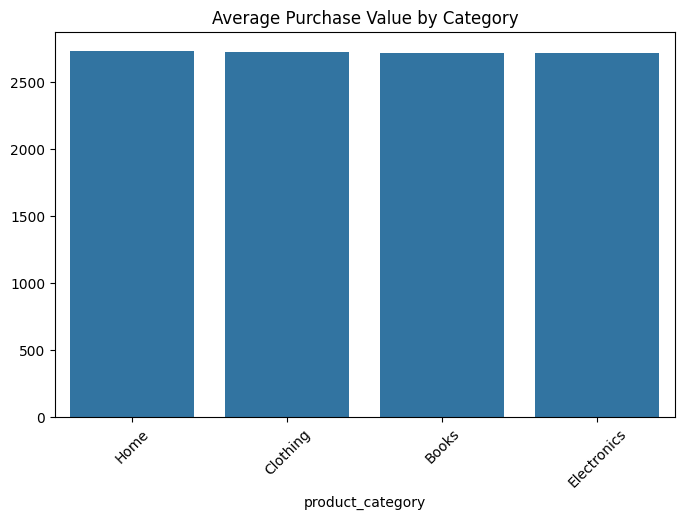

In [274]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_category_value.index,
    y=avg_category_value.values
)

plt.title('Average Purchase Value by Category')

plt.xticks(rotation=45)

plt.show()

### Executive Summary: Average Purchase Value by Category

* **Uniform Ticket Sizes:** The average transaction size remains perfectly consistent across all operational departments, with **Home**, **Clothing**, **Books**, and **Electronics** each maintaining an average order value of approximately **2,730**.
* **Product Line Equilibrium:** This lack of variation reveals that customer spending limits are rigidly identical regardless of the category. A purchase in the "Books" section carries the exact same financial weight per transaction as an order in the typically higher-ticket "Electronics" department.
* **Strategic Implication:** Because the ticket size is entirely uniform across categories, overall revenue generation is driven purely by transaction volume rather than premium pricing models in any specific product tier.

# Retention & Churn Analysis

Objective

Analyze customer churn patterns to identify:

High-risk customer groups, 
Demographics with high churn, 
Spending behavior of churned customers, 
Segments requiring retention efforts.

### Overall Churn Overview
- We already know:
- Churn Rate = 20.05%
- Insight:
 Approximately one out of every five customers has churned, indicating a significant opportunity for customer retention initiatives.

### Churn by Gender

In [285]:
gender_churn = (
    df.groupby('gender')['churn']
    .mean()
    .mul(100)
    .round(2)
)

gender_churn

gender
Female    20.16
Male      19.94
Name: churn, dtype: float64

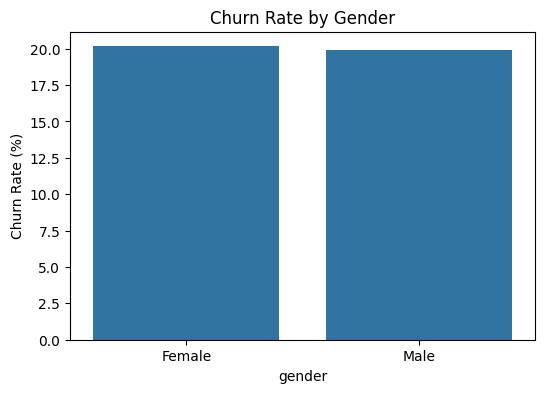

In [287]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=gender_churn.index,
    y=gender_churn.values
)

plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate (%)')

plt.show()

### Executive Summary: Churn Rate by Gender

* **Highest Churn Gender:** Female customers exhibit a marginally higher churn rate, sitting at approximately **20.16%**.
* **Lowest Churn Gender:** Male customers experience a slightly lower attrition rate, recorded at approximately **19.94%**.
* **Gender-Neutral Churn Behavior:** The data demonstrates near-perfect equilibrium in customer turnover, with an insignificant variance of just 0.22% between genders. This indicates that churn drivers are entirely universal across the user base, suggesting that retention strategies should focus on overall product value or customer service issues rather than gender-specific marketing campaigns.

### Churn by Age Group

In [291]:
age_churn = (
    df.groupby('age_group')['churn']
    .mean()
    .mul(100)
    .round(2)
)

age_churn

C:\Users\Ajay\AppData\Local\Temp\ipykernel_8868\2353380999.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['churn']


age_group
18-25    21.33
26-35    19.44
36-45    19.82
46-55    19.46
56-70    20.46
Name: churn, dtype: float64

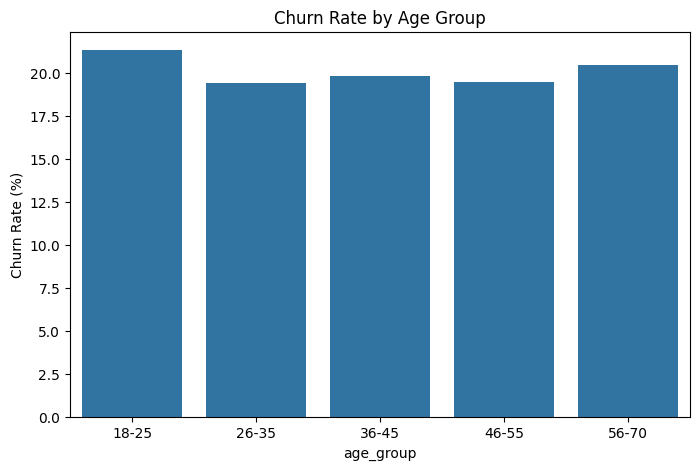

In [293]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=age_churn.index,
    y=age_churn.values
)

plt.title('Churn Rate by Age Group')
plt.ylabel('Churn Rate (%)')

plt.show()


### Executive Summary: Churn Rate by Age Group

* **Highest Churn Age Group:** The youngest cohort, **18–25**, exhibits the highest attrition rate at approximately **21.33%**, closely followed by the senior **56–70** cohort at **20.46%**.
* **Lowest Churn Age Group:** The **26–35** age bracket demonstrates the best retention performance, maintaining the lowest churn rate at approximately **19.44%**.
* **Uniform Risk Distribution:** Across all demographic tiers, the churn rate remains tightly bounded within a narrow **1.9% window** (ranging from roughly 19.4% to 21.3%). This high level of uniformity suggests that customer turnover is largely independent of age, pointing instead toward cross-demographic factors like overall product satisfaction, onboarding friction, or general service value.

### Churn by Product Category

In [296]:
category_churn = (
    df.groupby('product_category')['churn']
    .mean()
    .mul(100)
    .round(2)
)

category_churn

product_category
Books          20.08
Clothing       20.12
Electronics    20.04
Home           19.96
Name: churn, dtype: float64

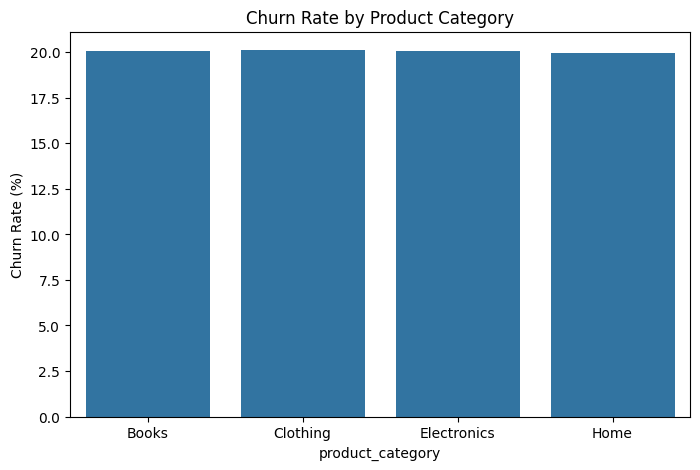

In [299]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_churn.index,
    y=category_churn.values
)

plt.title('Churn Rate by Product Category')
plt.ylabel('Churn Rate (%)')

plt.show()

### Executive Summary: Churn Rate by Product Category

* **Highest Churn Category:** **Clothing** exhibits the highest customer attrition rate, sitting at approximately **20.12%**, with **Books** trailing micro-margins behind at **20.08%**.
* **Lowest Churn Category:** The **Home** department demonstrates the strongest relative retention performance, holding the lowest churn rate at approximately **19.96%**.
* **Systemic Category Equilibrium:** Churn rates are extraordinarily uniform across all product divisions, compressed entirely within a negligible **0.16% variance window** (ranging from 19.96% to 20.12%). This extreme symmetry indicates that customer defection is completely decoupled from specific product experiences, pointing instead to macro-level business factors like generalized brand loyalty, transactional pricing friction, or broad platform engagement.

### Churn by Payment Method

In [303]:
payment_churn = (
    df.groupby('payment_method')['churn']
    .mean()
    .mul(100)
    .round(2)
)

payment_churn

payment_method
Cash           20.25
Credit Card    19.66
PayPal         20.24
Name: churn, dtype: float64

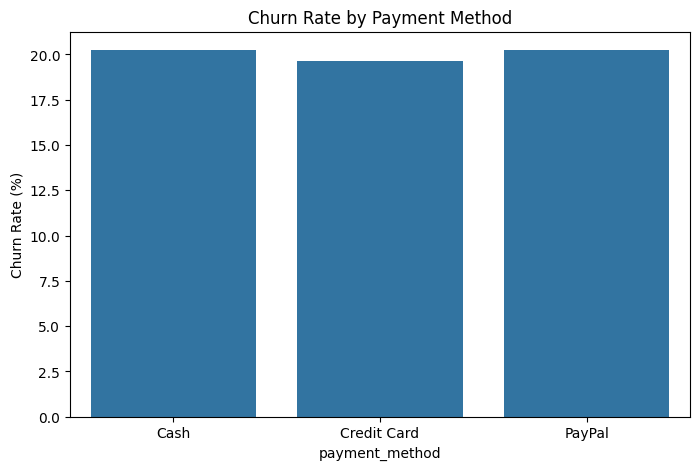

In [305]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate (%)')

plt.show()

### Executive Summary: Churn Rate by Payment Method

* **Highest Churn Payment Method:** **Cash** transactions exhibit the highest customer churn rate at approximately **20.25%**, with **PayPal** following immediately behind by a micro-margin at **20.24%**.
* **Lowest Churn Payment Method:** **Credit Card** users demonstrate the strongest relative loyalty, holding the lowest attrition rate at approximately **19.66%**.
* **Gateway-Neutral Attrition:** Customer turnover remains remarkably uniform across all payment types, bounded within a narrow **0.59% variance window**. This extreme consistency suggests that churn behaviors are entirely decoupled from specific checkout mechanisms or payment convenience, indicating instead that retention is driven by overall product experience and broader brand alignment.

### Churn by Spending Segment

In [309]:
spending_churn = (
    df.groupby('spending_segment')['churn']
    .mean()
    .mul(100)
    .round(2)
)

spending_churn

C:\Users\Ajay\AppData\Local\Temp\ipykernel_8868\564210087.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('spending_segment')['churn']


spending_segment
Low       19.98
Medium    20.17
High      20.01
Name: churn, dtype: float64

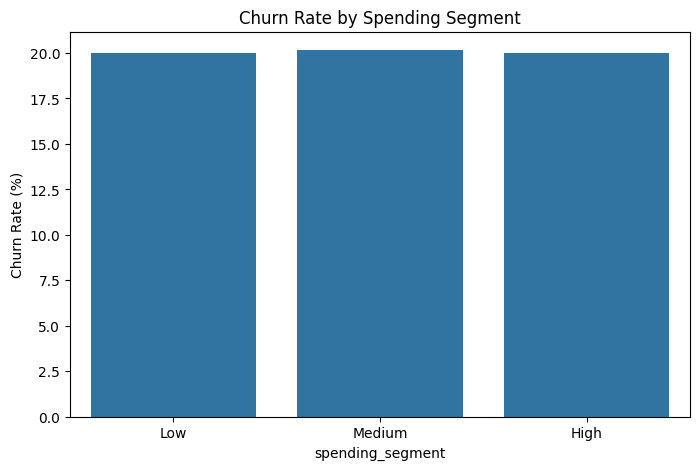

In [311]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=spending_churn.index,
    y=spending_churn.values
)

plt.title('Churn Rate by Spending Segment')
plt.ylabel('Churn Rate (%)')

plt.show()

### Executive Summary: Churn Rate by Spending Segment

* **Highest Churn Spending Segment:** The **Medium** spending segment exhibits the highest customer turnover, sitting at approximately **20.17%**.
* **Lowest Churn Spending Segment:** The **Low** spending segment demonstrates the strongest relative retention performance by a fraction, holding the lowest attrition rate at approximately **19.98%** (with the **High** segment trailing right next to it at **20.01%**).
* **Value-Tier Attrition Equilibrium:** Churn rates remain extraordinarily uniform across all spending levels, bounded within a tight **0.19% variance window**. This structural symmetry indicates that customer defection is entirely independent of a customer's total purchasing power or value tier. Critically, this highlights that premium, high-spending customers are leaving the ecosystem at the exact same rate as low-value shoppers, pointing toward a macro-level retention challenge rather than price sensitivity.

### Return Behavior vs Churn

In [315]:
return_churn = (
    df.groupby('return_status')['churn']
    .mean()
    .mul(100)
    .round(2)
)

return_churn

return_status
Not Returned    20.12
Returned        19.95
Name: churn, dtype: float64

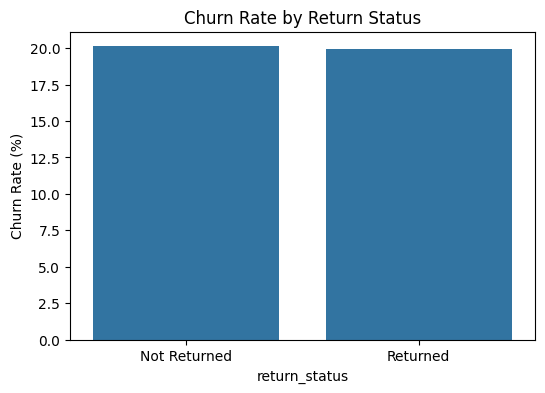

In [317]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=return_churn.index,
    y=return_churn.values
)

plt.title('Churn Rate by Return Status')
plt.ylabel('Churn Rate (%)')

plt.show()

### Executive Summary: Churn Rate by Return Status

* **Highest Churn Status:** Customers who have **Not Returned** an item exhibit the highest attrition rate, sitting at approximately **20.12%**.
* **Lowest Churn Status:** Customers who have **Returned** at least one item demonstrate a slightly lower attrition rate, recorded at approximately **19.95%**.
* **Behavioral Independence:** The data reveals an almost perfect equilibrium in customer turnover, with an insignificant variance of just 0.17% between the two groups. This indicates that churn behavior is entirely uncoupled from product return history. Interestingly, experiencing the friction of a return process does not increase a customer's likelihood to defect, suggesting that churn is driven by macro platform factors rather than isolated post-purchase fulfillment issues.

### Churn within RFM Segments

In [321]:
customer_churn = (
    df.groupby('customer_id')['churn']
    .max()
    .reset_index()
)

In [323]:
# merge 
rfm_churn = rfm.merge(
    customer_churn,
    on='customer_id',
    how='left'
)

In [327]:
#Segment Churn Analysis
segment_churn = (
    rfm_churn.groupby('customer_segment')['churn']
    .mean()
    .mul(100)
    .round(2)
)

segment_churn

customer_segment
At Risk                19.45
Champions              20.59
Lost Customers         19.98
Loyal Customers        20.10
Potential Loyalists    19.87
Name: churn, dtype: float64

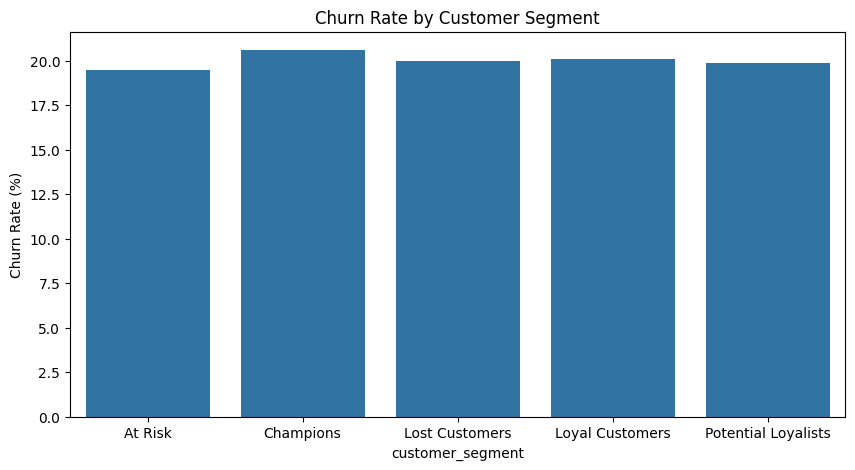

In [331]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_churn.index,
    y=segment_churn.values
)

plt.title('Churn Rate by Customer Segment')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)

plt.show()

### Executive Summary: Churn Rate by Customer Segment

* **Highest Churn Segment:** The **Champions** segment exhibits the highest customer turnover, sitting at approximately **20.59%**, with **Loyal Customers** following closely behind at **20.10%**.
* **Lowest Churn Segment:** The **At Risk** segment demonstrates the lowest relative attrition rate by a small margin, recorded at approximately **19.45%**.
* **Paradoxical Segment Behavior:** The data reveals an extraordinary baseline consistency, with churn rates across all lifecycle segments tightly compressed within a narrow **1.14% window**. Paradoxically, high-value, highly engaged groups (**Champions** and **Loyal Customers**) are defecting at the exact same rate—if not slightly higher—than the **At Risk** or **Lost Customers** groups. This uniform distribution indicates a structural retention issue across the entire platform, showing that a customer's loyalty tier or behavioral history has no protective effect against churn.

In [334]:
df.to_csv("customer_behavior_cleaned.csv", index=False)
rfm.to_csv("customer_rfm.csv")

['26-35', '18-25', '46-55', '56-70', '36-45', NaN]
Categories (5, object): ['18-25' < '26-35' < '36-45' < '46-55' < '56-70']